<a href="https://colab.research.google.com/github/aashifrizwan/airline-customer-analytics/blob/main/airline_customer_analysis_clean.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Airline Customer Analytics

This project analyses 500 fictional airline bookings to understand route performance, booking-channel behaviour, customer value and ancillary revenue.

The objective is to turn booking data into practical commercial recommendations for an airline’s digital, marketing and revenue teams.

## Analysis Objectives

1. Identify the routes generating the most bookings and revenue.
2. Compare the performance of direct and indirect booking channels.
3. Understand how booking lead time influences customer behaviour.
4. Identify the customer segments purchasing the most ancillary services.
5. Explore the relationship between loyalty membership and customer value.

> This project uses fictional data created solely for learning and portfolio purposes.

In [145]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

file_path = "/content/fictional_airline_bookings.xlsx"

df = pd.read_excel(
    file_path,
    sheet_name="Bookings"
)

df.head()

,booking_id,customer_id,booking_date,departure_date,origin,destination,route,booking_channel,trip_type,customer_type,loyalty_tier,passengers,base_fare_sar,ancillary_revenue_sar,total_revenue_sar,lead_time_days,repeat_customer
0,B00001,C0121,2025-05-24,2025-08-02,JED,CAI,JED-CAI,Website,One-way,Leisure,Basic,1,660,109,769,70,Yes
1,B00002,C0243,2025-06-16,2025-08-18,JED,CAI,JED-CAI,Website,Return,Visiting friends and relatives,Basic,1,599,145,744,63,Yes
2,B00003,C0103,2025-05-29,2025-07-05,RUH,TBS,RUH-TBS,Online Travel Agency,One-way,Leisure,Basic,3,2147,179,2326,37,Yes
3,B00004,C0024,2025-04-10,2025-05-19,RUH,IST,RUH-IST,Online Travel Agency,One-way,Business,Silver,2,1499,177,1676,39,Yes
4,B00005,C0020,2025-07-23,2025-07-25,RUH,DXB,RUH-DXB,Mobile App,Return,Visiting friends and relatives,Gold,3,2167,469,2636,2,Yes


## 1. Data Quality Check

Before beginning the analysis, the dataset is checked for its size, missing values and duplicate booking records.

In [146]:
print(f"Number of bookings: {df.shape[0]}")
print(f"Number of columns: {df.shape[1]}")
print(f"Duplicate booking IDs: {df['booking_id'].duplicated().sum()}")

missing_values = df.isnull().sum()
missing_values = missing_values[missing_values > 0]

print("\nMissing values by column:")
print(missing_values)

Number of bookings: 500
Number of columns: 17
Duplicate booking IDs: 0

Missing values by column:
loyalty_tier    181
dtype: int64


### Handling Missing Values

The missing values are limited to the `loyalty_tier` column. In this dataset, a blank loyalty tier represents a customer who is not enrolled in the airline’s loyalty programme.

These values are therefore replaced with `No membership` rather than deleting the affected bookings.

In [147]:
df["loyalty_tier"] = df["loyalty_tier"].fillna("No membership")

print("Missing values after cleaning:", df.isnull().sum().sum())

print("\nLoyalty tier distribution:")
print(df["loyalty_tier"].value_counts())

Missing values after cleaning: 0

Loyalty tier distribution:
loyalty_tier
Basic            214
No membership    181
Silver            80
Gold              25
Name: count, dtype: int64


## 2. Headline Performance

The following metrics provide an overall view of booking volume, customer reach, revenue and ancillary contribution.

In [148]:
total_bookings = len(df)
unique_customers = df["customer_id"].nunique()
total_revenue = df["total_revenue_sar"].sum()
average_booking_value = df["total_revenue_sar"].mean()
ancillary_revenue = df["ancillary_revenue_sar"].sum()
ancillary_share = ancillary_revenue / total_revenue

kpi_summary = pd.DataFrame({
    "Metric": [
        "Total Bookings",
        "Unique Customers",
        "Total Revenue",
        "Average Booking Value",
        "Ancillary Revenue",
        "Ancillary Share of Revenue"
    ],
    "Value": [
        f"{total_bookings:,}",
        f"{unique_customers:,}",
        f"SAR {total_revenue:,.0f}",
        f"SAR {average_booking_value:,.0f}",
        f"SAR {ancillary_revenue:,.0f}",
        f"{ancillary_share:.1%}"
    ]
})

kpi_summary

,Metric,Value
0,Total Bookings,500
1,Unique Customers,249
2,Total Revenue,"SAR 548,404"
3,Average Booking Value,"SAR 1,097"
4,Ancillary Revenue,"SAR 75,858"
5,Ancillary Share of Revenue,13.8%


### Headline Findings

The dataset contains 500 bookings from 249 unique customers, generating SAR 548,404 in total revenue.

The average booking generated approximately SAR 1,097. Ancillary products contributed SAR 75,858, representing 13.8% of total revenue.

## 3. Route Performance

Route performance is assessed using booking volume, total revenue and average booking value.

In [149]:
route_performance = (
    df.groupby("route")
      .agg(
          bookings=("booking_id", "count"),
          total_revenue_sar=("total_revenue_sar", "sum"),
          average_booking_value_sar=("total_revenue_sar", "mean")
      )
      .sort_values("total_revenue_sar", ascending=False)
      .reset_index()
)

route_performance.style.format({
    "total_revenue_sar": "SAR {:,.0f}",
    "average_booking_value_sar": "SAR {:,.0f}"
})

,route,bookings,total_revenue_sar,average_booking_value_sar
0,JED-CAI,57,"SAR 64,781","SAR 1,137"
1,RUH-IST,39,"SAR 62,499","SAR 1,603"
2,TBS-RUH,41,"SAR 61,773","SAR 1,507"
3,RUH-TBS,43,"SAR 57,510","SAR 1,337"
4,IST-RUH,37,"SAR 56,044","SAR 1,515"
5,CAI-JED,36,"SAR 53,784","SAR 1,494"
6,RUH-DXB,42,"SAR 45,918","SAR 1,093"
7,JED-DMM,58,"SAR 40,366",SAR 696
8,DXB-RUH,32,"SAR 33,964","SAR 1,061"
9,JED-RUH,46,"SAR 28,887",SAR 628


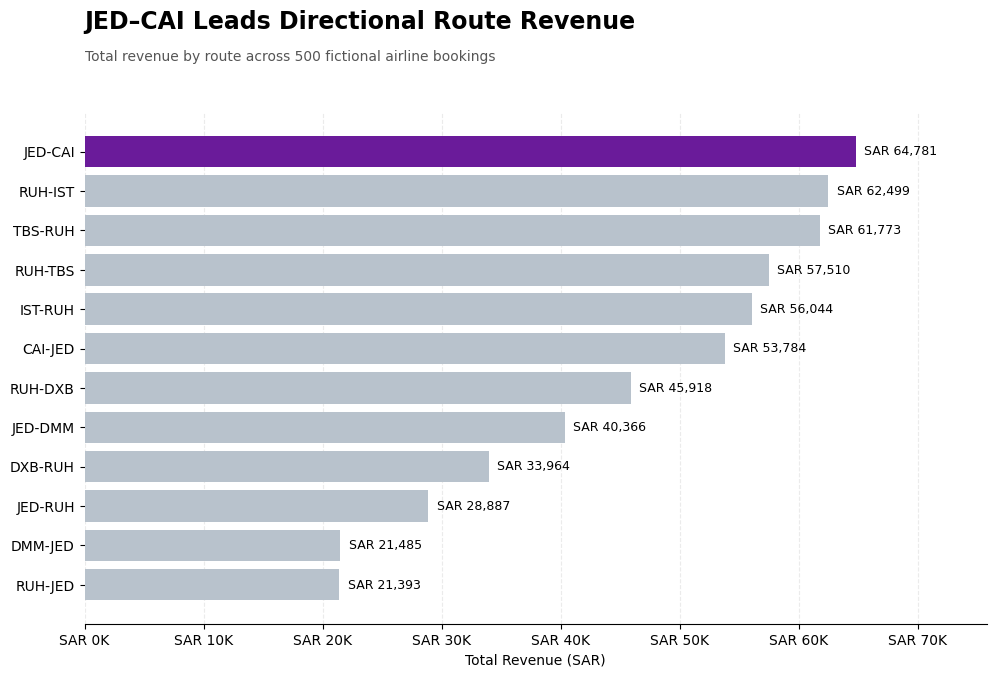

In [150]:
route_chart = route_performance.sort_values(
    "total_revenue_sar",
    ascending=True
)

fig, ax = plt.subplots(figsize=(11, 7))

colors = [
    "#6A1B9A" if route == "JED-CAI" else "#B8C2CC"
    for route in route_chart["route"]
]

bars = ax.barh(
    route_chart["route"],
    route_chart["total_revenue_sar"],
    color=colors
)

ax.set_xlim(0, route_chart["total_revenue_sar"].max() * 1.17)

fig.subplots_adjust(
    top=0.83,
    left=0.13,
    right=0.95,
    bottom=0.10
)

fig.text(
    0.13,
    0.95,
    "JED–CAI Leads Directional Route Revenue",
    fontsize=17,
    fontweight="bold",
    ha="left"
)

fig.text(
    0.13,
    0.905,
    "Total revenue by route across 500 fictional airline bookings",
    fontsize=10,
    color="#555555",
    ha="left"
)

ax.set_xlabel("Total Revenue (SAR)")
ax.set_ylabel("")

ax.xaxis.set_major_formatter(
    FuncFormatter(lambda value, position: f"SAR {value / 1000:.0f}K")
)

for bar, value in zip(bars, route_chart["total_revenue_sar"]):
    ax.text(
        value + 700,
        bar.get_y() + bar.get_height() / 2,
        f"SAR {value:,.0f}",
        va="center",
        fontsize=9
    )

ax.grid(axis="x", linestyle="--", alpha=0.25)
ax.set_axisbelow(True)

for side in ["top", "right", "left"]:
    ax.spines[side].set_visible(False)

plt.savefig(
    "/content/route_revenue_by_route.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Route Performance Findings

- **JED–CAI generated the highest total revenue at SAR 64,781**, supported by 57 bookings and an average booking value of approximately SAR 1,137.
- **RUH–IST ranked second for revenue despite recording only 39 bookings.** Its average booking value of approximately SAR 1,603 was the highest across all routes.
- **JED–DMM recorded the highest booking volume with 58 bookings**, but ranked eighth for revenue because its average booking value was considerably lower at approximately SAR 696.
- Booking volume alone does not determine route value. Higher-value international routes can outperform higher-volume domestic routes.

## 4. Booking-Channel Performance

Booking channels are compared using booking volume, revenue, average booking value and ancillary contribution.

In [151]:
channel_performance = (
    df.groupby("booking_channel")
      .agg(
          bookings=("booking_id", "count"),
          total_revenue_sar=("total_revenue_sar", "sum"),
          average_booking_value_sar=("total_revenue_sar", "mean"),
          ancillary_revenue_sar=("ancillary_revenue_sar", "sum")
      )
      .reset_index()
)

channel_performance["booking_share"] = (
    channel_performance["bookings"] / total_bookings
)

channel_performance["revenue_share"] = (
    channel_performance["total_revenue_sar"] / total_revenue
)

channel_performance["ancillary_share"] = (
    channel_performance["ancillary_revenue_sar"]
    / channel_performance["total_revenue_sar"]
)

channel_performance = channel_performance.sort_values(
    "total_revenue_sar",
    ascending=False
)

channel_performance.style.format({
    "total_revenue_sar": "SAR {:,.0f}",
    "average_booking_value_sar": "SAR {:,.0f}",
    "ancillary_revenue_sar": "SAR {:,.0f}",
    "booking_share": "{:.1%}",
    "revenue_share": "{:.1%}",
    "ancillary_share": "{:.1%}"
})

,booking_channel,bookings,total_revenue_sar,average_booking_value_sar,ancillary_revenue_sar,booking_share,revenue_share,ancillary_share
3,Website,202,"SAR 218,669","SAR 1,083","SAR 30,939",40.4%,39.9%,14.1%
0,Mobile App,174,"SAR 185,980","SAR 1,069","SAR 26,011",34.8%,33.9%,14.0%
1,Online Travel Agency,88,"SAR 104,230","SAR 1,184","SAR 13,675",17.6%,19.0%,13.1%
2,Travel Agent,36,"SAR 39,525","SAR 1,098","SAR 5,233",7.2%,7.2%,13.2%


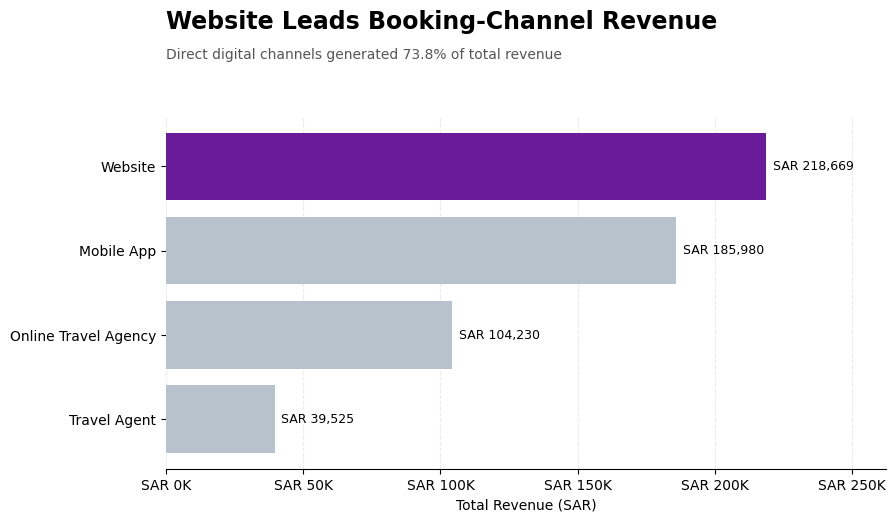

In [152]:
direct_channels = ["Website", "Mobile App"]

direct_revenue_share = (
    df.loc[
        df["booking_channel"].isin(direct_channels),
        "total_revenue_sar"
    ].sum() / total_revenue
)

channel_chart = channel_performance.sort_values(
    "total_revenue_sar",
    ascending=True
)

fig, ax = plt.subplots(figsize=(10, 5.5))

colors = [
    "#6A1B9A" if channel == "Website" else "#B8C2CC"
    for channel in channel_chart["booking_channel"]
]

bars = ax.barh(
    channel_chart["booking_channel"],
    channel_chart["total_revenue_sar"],
    color=colors
)

ax.set_xlim(0, channel_chart["total_revenue_sar"].max() * 1.20)

fig.subplots_adjust(
    top=0.78,
    left=0.20,
    right=0.92,
    bottom=0.14
)

fig.text(
    0.20,
    0.94,
    "Website Leads Booking-Channel Revenue",
    fontsize=17,
    fontweight="bold",
    ha="left"
)

fig.text(
    0.20,
    0.885,
    f"Direct digital channels generated {direct_revenue_share:.1%} of total revenue",
    fontsize=10,
    color="#555555",
    ha="left"
)

ax.set_xlabel("Total Revenue (SAR)")
ax.set_ylabel("")

ax.xaxis.set_major_formatter(
    FuncFormatter(lambda value, position: f"SAR {value / 1000:.0f}K")
)

for bar, value in zip(bars, channel_chart["total_revenue_sar"]):
    ax.text(
        value + 2500,
        bar.get_y() + bar.get_height() / 2,
        f"SAR {value:,.0f}",
        va="center",
        fontsize=9
    )

ax.grid(axis="x", linestyle="--", alpha=0.25)
ax.set_axisbelow(True)

for side in ["top", "right", "left"]:
    ax.spines[side].set_visible(False)

plt.savefig(
    "/content/channel_revenue.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Booking-Channel Findings

- The **Website** generated 202 bookings and SAR 218,669, making it the largest channel by both volume and revenue.
- The **Mobile App** ranked second with 174 bookings and SAR 185,980.
- Website and Mobile App combined generated **75.2% of bookings and 73.8% of revenue**, demonstrating the importance of direct digital channels.
- Online Travel Agencies produced the highest average booking value at approximately SAR 1,184, despite contributing only 17.6% of bookings.
- The results suggest that the airline should continue strengthening direct-channel conversion and retention while using OTAs selectively for customer acquisition and market reach.

## 5. Booking Lead Time

Customers are grouped according to how many days before departure they made their booking. This helps assess the relationship between booking urgency and customer value.

In [153]:
lead_time_labels = [
    "1–7 days",
    "8–21 days",
    "22–45 days",
    "46–90 days"
]

df["lead_time_band"] = pd.cut(
    df["lead_time_days"],
    bins=[0, 7, 21, 45, 90],
    labels=lead_time_labels,
    include_lowest=True
)

lead_time_performance = (
    df.groupby("lead_time_band", observed=False)
      .agg(
          bookings=("booking_id", "count"),
          average_base_fare_sar=("base_fare_sar", "mean"),
          average_booking_value_sar=("total_revenue_sar", "mean"),
          total_revenue_sar=("total_revenue_sar", "sum")
      )
      .reset_index()
)

lead_time_performance.style.format({
    "average_base_fare_sar": "SAR {:,.0f}",
    "average_booking_value_sar": "SAR {:,.0f}",
    "total_revenue_sar": "SAR {:,.0f}"
})

,lead_time_band,bookings,average_base_fare_sar,average_booking_value_sar,total_revenue_sar
0,1–7 days,51,"SAR 1,240","SAR 1,400","SAR 71,415"
1,8–21 days,72,"SAR 1,194","SAR 1,357","SAR 97,696"
2,22–45 days,131,SAR 888,"SAR 1,038","SAR 136,036"
3,46–90 days,246,SAR 842,SAR 989,"SAR 243,257"


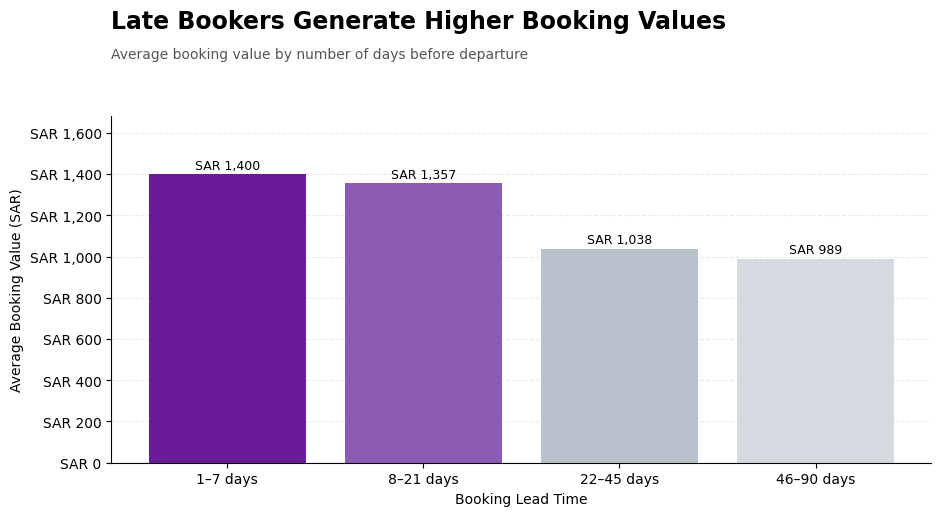

In [154]:
fig, ax = plt.subplots(figsize=(10, 5.5))

bars = ax.bar(
    lead_time_performance["lead_time_band"].astype(str),
    lead_time_performance["average_booking_value_sar"],
    color=["#6A1B9A", "#8C5BB3", "#B8C2CC", "#D4DAE0"]
)

ax.set_ylim(
    0,
    lead_time_performance["average_booking_value_sar"].max() * 1.20
)

fig.subplots_adjust(
    top=0.78,
    left=0.13,
    right=0.95,
    bottom=0.15
)

fig.text(
    0.13,
    0.94,
    "Late Bookers Generate Higher Booking Values",
    fontsize=17,
    fontweight="bold",
    ha="left"
)

fig.text(
    0.13,
    0.885,
    "Average booking value by number of days before departure",
    fontsize=10,
    color="#555555",
    ha="left"
)

ax.set_xlabel("Booking Lead Time")
ax.set_ylabel("Average Booking Value (SAR)")

ax.yaxis.set_major_formatter(
    FuncFormatter(lambda value, position: f"SAR {value:,.0f}")
)

for bar, value in zip(
    bars,
    lead_time_performance["average_booking_value_sar"]
):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        value + 25,
        f"SAR {value:,.0f}",
        ha="center",
        fontsize=9
    )

ax.grid(axis="y", linestyle="--", alpha=0.25)
ax.set_axisbelow(True)

for side in ["top", "right"]:
    ax.spines[side].set_visible(False)

plt.savefig(
    "/content/lead_time_booking_value.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Lead-Time Findings

- Customers booking **1–7 days before departure** produced the highest average booking value at approximately SAR 1,400.
- Customers booking **8–21 days before departure** generated an average booking value of approximately SAR 1,357.
- Customers booking **46–90 days in advance** generated the lowest average booking value at approximately SAR 989.
- Late-booking customers appear less price-sensitive and may represent an opportunity for targeted premium services and higher-value ancillary offers.
- Early bookers account for more bookings overall, making them important for advance demand generation and promotional campaigns.

## 6. Ancillary Revenue by Customer Type

Ancillary behaviour is analysed by customer type to identify which segments spend the most on optional services such as baggage and seat selection.

In [155]:
customer_type_performance = (
    df.groupby("customer_type")
      .agg(
          bookings=("booking_id", "count"),
          total_revenue_sar=("total_revenue_sar", "sum"),
          ancillary_revenue_sar=("ancillary_revenue_sar", "sum"),
          average_ancillary_sar=("ancillary_revenue_sar", "mean")
      )
      .sort_values("average_ancillary_sar", ascending=False)
      .reset_index()
)

customer_type_performance["ancillary_share"] = (
    customer_type_performance["ancillary_revenue_sar"]
    / customer_type_performance["total_revenue_sar"]
)

customer_type_performance.style.format({
    "total_revenue_sar": "SAR {:,.0f}",
    "ancillary_revenue_sar": "SAR {:,.0f}",
    "average_ancillary_sar": "SAR {:,.0f}",
    "ancillary_share": "{:.1%}"
})

,customer_type,bookings,total_revenue_sar,ancillary_revenue_sar,average_ancillary_sar,ancillary_share
0,Visiting friends and relatives,130,"SAR 140,110","SAR 22,987",SAR 177,16.4%
1,Leisure,288,"SAR 318,694","SAR 44,150",SAR 153,13.9%
2,Business,82,"SAR 89,600","SAR 8,721",SAR 106,9.7%


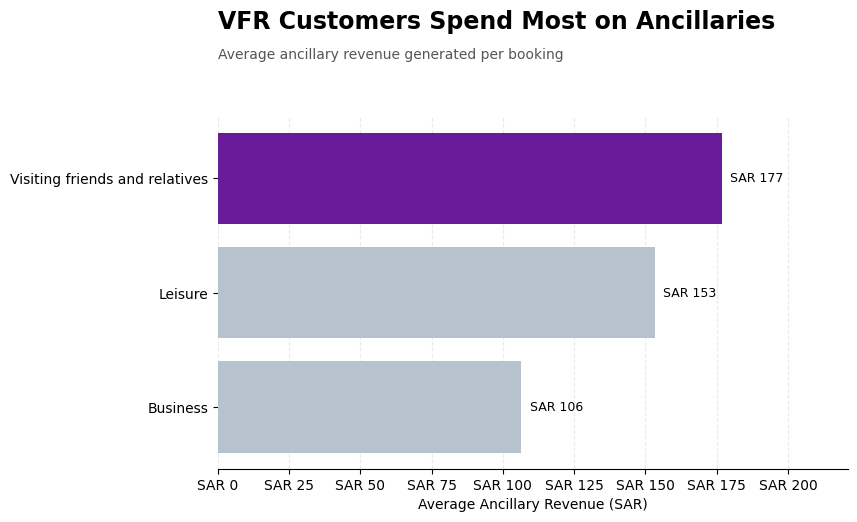

In [156]:
ancillary_chart = customer_type_performance.sort_values(
    "average_ancillary_sar",
    ascending=True
)

fig, ax = plt.subplots(figsize=(10, 5.5))

colors = [
    "#6A1B9A"
    if customer == "Visiting friends and relatives"
    else "#B8C2CC"
    for customer in ancillary_chart["customer_type"]
]

bars = ax.barh(
    ancillary_chart["customer_type"],
    ancillary_chart["average_ancillary_sar"],
    color=colors
)

ax.set_xlim(
    0,
    ancillary_chart["average_ancillary_sar"].max() * 1.25
)

fig.subplots_adjust(
    top=0.78,
    left=0.31,
    right=0.94,
    bottom=0.14
)

fig.text(
    0.31,
    0.94,
    "VFR Customers Spend Most on Ancillaries",
    fontsize=17,
    fontweight="bold",
    ha="left"
)

fig.text(
    0.31,
    0.885,
    "Average ancillary revenue generated per booking",
    fontsize=10,
    color="#555555",
    ha="left"
)

ax.set_xlabel("Average Ancillary Revenue (SAR)")
ax.set_ylabel("")

ax.xaxis.set_major_formatter(
    FuncFormatter(lambda value, position: f"SAR {value:,.0f}")
)

for bar, value in zip(
    bars,
    ancillary_chart["average_ancillary_sar"]
):
    ax.text(
        value + 3,
        bar.get_y() + bar.get_height() / 2,
        f"SAR {value:,.0f}",
        va="center",
        fontsize=9
    )

ax.grid(axis="x", linestyle="--", alpha=0.25)
ax.set_axisbelow(True)

for side in ["top", "right", "left"]:
    ax.spines[side].set_visible(False)

plt.savefig(
    "/content/ancillary_by_customer_type.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Ancillary Findings

- Customers visiting friends and relatives generated the highest average ancillary revenue at approximately **SAR 177 per booking**.
- Leisure travellers followed at approximately **SAR 153 per booking**.
- Business travellers generated the lowest average ancillary revenue at approximately **SAR 106 per booking**.
- Baggage, seat and flexibility bundles could be promoted more prominently to visiting-friends-and-relatives and leisure segments.
- Business customers may require different products, such as priority services, flexibility and time-saving benefits.

## 7. Loyalty and Customer Value

Average booking and ancillary values are compared across loyalty tiers to understand whether programme membership is associated with higher customer value.

In [157]:
loyalty_performance = (
    df.groupby("loyalty_tier")
      .agg(
          bookings=("booking_id", "count"),
          unique_customers=("customer_id", "nunique"),
          total_revenue_sar=("total_revenue_sar", "sum"),
          average_booking_value_sar=("total_revenue_sar", "mean"),
          average_ancillary_sar=("ancillary_revenue_sar", "mean")
      )
      .sort_values("average_booking_value_sar", ascending=False)
      .reset_index()
)

loyalty_performance.style.format({
    "total_revenue_sar": "SAR {:,.0f}",
    "average_booking_value_sar": "SAR {:,.0f}",
    "average_ancillary_sar": "SAR {:,.0f}"
})

,loyalty_tier,bookings,unique_customers,total_revenue_sar,average_booking_value_sar,average_ancillary_sar
0,Silver,80,68,"SAR 102,992","SAR 1,287",SAR 183
1,Gold,25,25,"SAR 30,969","SAR 1,239",SAR 182
2,Basic,214,163,"SAR 227,828","SAR 1,065",SAR 143
3,No membership,181,137,"SAR 186,615","SAR 1,031",SAR 144


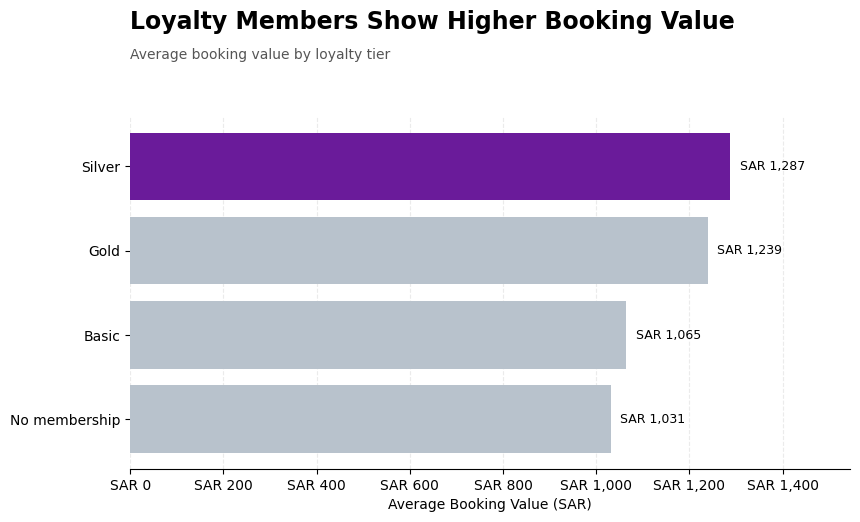

In [158]:
loyalty_chart = loyalty_performance.sort_values(
    "average_booking_value_sar",
    ascending=True
)

fig, ax = plt.subplots(figsize=(10, 5.5))

colors = [
    "#6A1B9A" if tier == "Silver" else "#B8C2CC"
    for tier in loyalty_chart["loyalty_tier"]
]

bars = ax.barh(
    loyalty_chart["loyalty_tier"],
    loyalty_chart["average_booking_value_sar"],
    color=colors
)

ax.set_xlim(
    0,
    loyalty_chart["average_booking_value_sar"].max() * 1.20
)

fig.subplots_adjust(
    top=0.78,
    left=0.20,
    right=0.92,
    bottom=0.14
)

fig.text(
    0.20,
    0.94,
    "Loyalty Members Show Higher Booking Value",
    fontsize=17,
    fontweight="bold",
    ha="left"
)

fig.text(
    0.20,
    0.885,
    "Average booking value by loyalty tier",
    fontsize=10,
    color="#555555",
    ha="left"
)

ax.set_xlabel("Average Booking Value (SAR)")
ax.set_ylabel("")

ax.xaxis.set_major_formatter(
    FuncFormatter(lambda value, position: f"SAR {value:,.0f}")
)

for bar, value in zip(
    bars,
    loyalty_chart["average_booking_value_sar"]
):
    ax.text(
        value + 20,
        bar.get_y() + bar.get_height() / 2,
        f"SAR {value:,.0f}",
        va="center",
        fontsize=9
    )

ax.grid(axis="x", linestyle="--", alpha=0.25)
ax.set_axisbelow(True)

for side in ["top", "right", "left"]:
    ax.spines[side].set_visible(False)

plt.savefig(
    "/content/loyalty_booking_value.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Loyalty Findings

- Silver members generated the highest average booking value at approximately **SAR 1,287**.
- Gold members followed at approximately **SAR 1,239**, although the Gold sample contains only 25 bookings and should therefore be interpreted cautiously.
- Customers without a loyalty membership produced the lowest average booking value at approximately **SAR 1,031**.
- Silver and Gold members also generated approximately SAR 182 in average ancillary revenue, compared with approximately SAR 144 among Basic members and non-members.
- Loyalty membership is associated with higher customer value in this dataset, although the analysis does not establish causation.

## 8. Repeat-Customer Behaviour

Repeat and non-repeat bookings are compared to examine whether returning customers generate greater commercial value.

In [159]:
repeat_performance = (
    df.groupby("repeat_customer")
      .agg(
          bookings=("booking_id", "count"),
          total_revenue_sar=("total_revenue_sar", "sum"),
          average_booking_value_sar=("total_revenue_sar", "mean"),
          average_ancillary_sar=("ancillary_revenue_sar", "mean")
      )
      .reset_index()
)

repeat_performance["booking_share"] = (
    repeat_performance["bookings"] / total_bookings
)

repeat_performance.style.format({
    "total_revenue_sar": "SAR {:,.0f}",
    "average_booking_value_sar": "SAR {:,.0f}",
    "average_ancillary_sar": "SAR {:,.0f}",
    "booking_share": "{:.1%}"
})

,repeat_customer,bookings,total_revenue_sar,average_booking_value_sar,average_ancillary_sar,booking_share
0,No,64,"SAR 64,736","SAR 1,012",SAR 142,12.8%
1,Yes,436,"SAR 483,668","SAR 1,109",SAR 153,87.2%


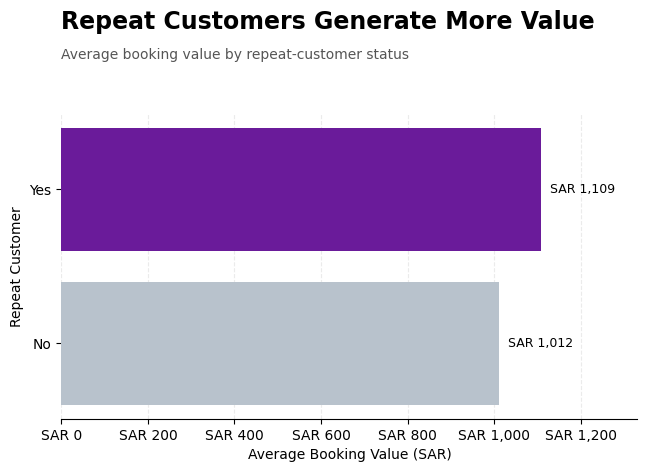

In [160]:
repeat_chart = repeat_performance.sort_values(
    "average_booking_value_sar",
    ascending=True
)

fig, ax = plt.subplots(figsize=(8, 5))

colors = [
    "#6A1B9A" if status == "Yes" else "#B8C2CC"
    for status in repeat_chart["repeat_customer"]
]

bars = ax.barh(
    repeat_chart["repeat_customer"],
    repeat_chart["average_booking_value_sar"],
    color=colors
)

ax.set_xlim(
    0,
    repeat_chart["average_booking_value_sar"].max() * 1.20
)

fig.subplots_adjust(
    top=0.76,
    left=0.20,
    right=0.92,
    bottom=0.15
)

fig.text(
    0.20,
    0.93,
    "Repeat Customers Generate More Value",
    fontsize=17,
    fontweight="bold",
    ha="left"
)

fig.text(
    0.20,
    0.87,
    "Average booking value by repeat-customer status",
    fontsize=10,
    color="#555555",
    ha="left"
)

ax.set_xlabel("Average Booking Value (SAR)")
ax.set_ylabel("Repeat Customer")

ax.xaxis.set_major_formatter(
    FuncFormatter(lambda value, position: f"SAR {value:,.0f}")
)

for bar, value in zip(
    bars,
    repeat_chart["average_booking_value_sar"]
):
    ax.text(
        value + 20,
        bar.get_y() + bar.get_height() / 2,
        f"SAR {value:,.0f}",
        va="center",
        fontsize=9
    )

ax.grid(axis="x", linestyle="--", alpha=0.25)
ax.set_axisbelow(True)

for side in ["top", "right", "left"]:
    ax.spines[side].set_visible(False)

plt.savefig(
    "/content/repeat_customer_value.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Repeat-Customer Findings

- Repeat customers generated an average booking value of approximately **SAR 1,109**, compared with SAR 1,012 among non-repeat customers.
- Repeat customers also generated slightly higher average ancillary revenue at approximately **SAR 153**, compared with SAR 142 among non-repeat customers.
- The results indicate that returning customers are associated with greater booking and ancillary value.
- Lifecycle communication, loyalty enrolment and personalised re-engagement could therefore support long-term customer value.

## 9. Commercial Recommendations

### 1. Prioritise Value, Not Only Booking Volume

Route decisions should consider average booking value and total revenue alongside booking volume. Higher-value routes such as RUH–IST can commercially outperform higher-volume domestic routes.

### 2. Strengthen Direct Digital Channels

Website and Mobile App generated 73.8% of total revenue. The airline should continue improving direct-channel conversion, personalisation, app adoption and customer retention.

### 3. Develop Segment-Specific Ancillary Offers

Visiting-friends-and-relatives and leisure customers generated the highest ancillary value. Relevant baggage, seat and travel bundles should be presented during booking and through pre-departure communication.

### 4. Target Late Bookers With High-Value Products

Customers booking within 21 days of departure generated higher average booking values. These customers may be receptive to flexibility, priority and convenience-based services.

### 5. Expand Loyalty Enrolment and Retention

Silver and Gold members generated higher booking and ancillary values than non-members. The airline should test loyalty-enrolment prompts and personalised member offers across the booking journey.

## Limitations

- The dataset is fictional and contains only 500 bookings.
- The analysis identifies relationships but does not prove that one factor causes another.
- Operational measures such as capacity, load factor, flight frequency and route costs are not included.
- Customer segments are simplified and may not represent real airline segmentation.
- Further analysis with larger historical datasets would be required before making actual commercial decisions.

In [161]:
df.to_csv(
    "/content/cleaned_airline_bookings.csv",
    index=False
)

print("Cleaned dataset exported successfully.")

Cleaned dataset exported successfully.
